In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve,
    auc,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from xgboost import XGBRegressor

## Load file

In [2]:
X_Uncleaned = pd.read_csv("./X.csv")
y_Uncleaned = pd.read_csv("./y.csv")

X = X_Uncleaned.iloc[:, 1:]  # remove index
y = y_Uncleaned.iloc[:, 1:]  # remove index

# display(y.head())

In [3]:
loadPickleFile = pd.read_pickle("./xgb_model_withgpa.pkl")
# print(loadPickleFile)

### Preprocess X and Y

In [4]:
# Stratify on binary depression status just to keep it balanced
y_binary = np.where(y >= 10, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_binary, random_state=42
)

y_train_binary = np.where(y_train >= 10, 1, 0)
y_test_binary = np.where(y_test >= 10, 1, 0)

### Build Model

In [5]:
# Extract the hyperparams
params_xg = (
    loadPickleFile.get_params()
)  # --> Used to get paramters of a fresh model (not trained yet)

### Checking current status of sample

In [6]:
print("Shape of sample:", X_train.shape)
print("Class distribution:", np.bincount(y_train_binary.ravel()))

Shape of sample: (7202, 33)
Class distribution: [5752 1450]


## Step 2A: Baseline Training (No Balancing)

In [7]:
model_baseline = XGBRegressor(**params_xg)
model_baseline.fit(X_train, y_train)

y_pred_scores_baseline = model_baseline.predict(X_test)
y_pred_binary_baseline = np.where(y_pred_scores_baseline >= 10, 1, 0)

In [8]:
# Evaluate baseline XGBoost
metrics_baseline_xgb = {
    "accuracy": accuracy_score(y_test_binary, y_pred_binary_baseline),
    "precision": precision_score(y_test_binary, y_pred_binary_baseline),
    "recall": recall_score(y_test_binary, y_pred_binary_baseline),
    "f1": f1_score(y_test_binary, y_pred_binary_baseline),
    "auc": roc_auc_score(y_test_binary, y_pred_scores_baseline),
}

The model achieved an overall accuracy of 95%, with precision and F1-scores appearing strong at first glance. However, closer inspection reveals a critical issue related to class imbalance.

## Step 2B: Undersampling the Majority Class

In [9]:
# Count the number of 0s and 1s in y_train_binary
counter = Counter(y_train_binary.ravel())
minority_class_count = counter[1]
majority_class_count = counter[0]

print(f"Minority class count:", minority_class_count)
print(f"Majority class count:", majority_class_count)

Minority class count: 1450
Majority class count: 5752


In [10]:
# For 1.5:1 (majority = 1.5x minority)
desired_majority_count_1_5 = int(1.5 * minority_class_count)
sampling_strategy_1_5to1 = minority_class_count / desired_majority_count_1_5

print(f"Sampling strategy for 1.5:1:", sampling_strategy_1_5to1)

Sampling strategy for 1.5:1: 0.6666666666666666


In [11]:
# For 2:1 (majority = 2x minority)
desired_majority_count_2 = int(2.0 * minority_class_count)
sampling_strategy_2to1 = minority_class_count / desired_majority_count_2

print(f"Sampling strategy for 2:1:", sampling_strategy_2to1)

Sampling strategy for 2:1: 0.5


### Functions to undersample based on selected ratios

In [12]:
# Function: Perform Random Undersampling on the training data
# Inputs:
#   - X_train: Features for training
#   - y_train: Continuous PHQ-9 scores for training
#   - y_train_binary: Binary 0/1 labels for training (used for sampling)
#   - sampling_ratio: Desired ratio of minority to majority class (e.g., 1.0 for 1:1)
# Outputs:
#   - X_train_under: Features after undersampling
#   - y_train_under_continuous: Continuous PHQ-9 scores corresponding to sampled features
def undersample_data(X_train, y_train, y_train_binary, sampling_ratio):
    undersampler = RandomUnderSampler(sampling_strategy=sampling_ratio, random_state=42)
    X_train_under, y_train_under_binary = undersampler.fit_resample(
        X_train, y_train_binary
    )

    # Match the sampled features with original continuous labels
    selected_indices = undersampler.sample_indices_
    y_train_under_continuous = y_train.iloc[selected_indices].reset_index(drop=True)

    return X_train_under, y_train_under_continuous

In [13]:
def train_and_evaluate_xgboost(
    X_train_under,
    y_train_under_continuous,
    X_test,
    y_test_binary,
    params,
    model_label="XGBoost",
):
    model = XGBRegressor(**params)
    model.fit(X_train_under, y_train_under_continuous)

    y_pred_scores = model.predict(X_test)
    y_pred_binary = (y_pred_scores >= 10).astype(int)

    # Metrics
    metrics = {
        "accuracy": accuracy_score(y_test_binary, y_pred_binary),
        "precision": precision_score(y_test_binary, y_pred_binary),
        "recall": recall_score(y_test_binary, y_pred_binary),
        "f1": f1_score(y_test_binary, y_pred_binary),
        "auc": roc_auc_score(y_test_binary, y_pred_scores),
    }

    # Console output
    print(f"\n=== Evaluation for {model_label} ===")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test_binary, y_pred_binary)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test_binary, y_pred_binary, digits=3))

    # Plot confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted: 0", "Predicted: 1"],
        yticklabels=["Actual: 0", "Actual: 1"],
    )
    plt.title(f"Confusion Matrix: {model_label}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return y_pred_scores, y_pred_binary, metrics

### 1:1 Random Undersampling


=== Evaluation for XGBoost ===
Confusion Matrix:
[[1352   87]
 [   0  362]]

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.940     0.969      1439
           1      0.806     1.000     0.893       362

    accuracy                          0.952      1801
   macro avg      0.903     0.970     0.931      1801
weighted avg      0.961     0.952     0.954      1801



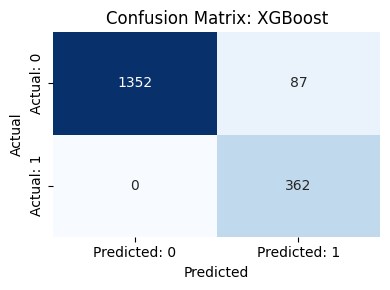

In [14]:
# Step 1: Undersample at 1:1 ratio
X_train_under_1to1, y_train_under_continuous_1to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=1.0
)

# Step 2: Train and evaluate on 1:1 undersampled data
y_pred_scores_1to1, y_pred_binary_1to1, metrics_1to1 = train_and_evaluate_xgboost(
    X_train_under_1to1, y_train_under_continuous_1to1, X_test, y_test_binary, params_xg
)

### 1.5:1 Ratio (Moderate Undersampling)


=== Evaluation for XGBoost ===
Confusion Matrix:
[[1353   86]
 [   4  358]]

Classification Report:
              precision    recall  f1-score   support

           0      0.997     0.940     0.968      1439
           1      0.806     0.989     0.888       362

    accuracy                          0.950      1801
   macro avg      0.902     0.965     0.928      1801
weighted avg      0.959     0.950     0.952      1801



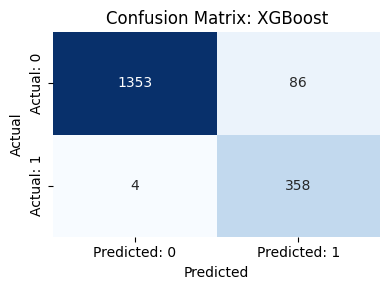

In [15]:
# Step 1: Undersample at 1.5:1 ratio
X_train_under_1_5to1, y_train_under_continuous_1_5to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=sampling_strategy_1_5to1
)

# Step 2: Train and evaluate on 1.5:1 undersampled data
y_pred_scores_1_5to1, y_pred_binary_1_5to1, metrics_1_5to1 = train_and_evaluate_xgboost(
    X_train_under_1_5to1,
    y_train_under_continuous_1_5to1,
    X_test,
    y_test_binary,
    params_xg,
)

### 2:1 Ratio (Light Undersampling)


=== Evaluation for XGBoost ===
Confusion Matrix:
[[1415   24]
 [  82  280]]

Classification Report:
              precision    recall  f1-score   support

           0      0.945     0.983     0.964      1439
           1      0.921     0.773     0.841       362

    accuracy                          0.941      1801
   macro avg      0.933     0.878     0.902      1801
weighted avg      0.940     0.941     0.939      1801



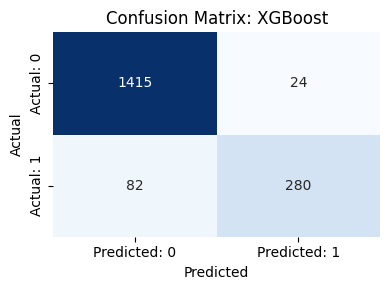

In [16]:
# Step 1: Undersample at 2:1 ratio
X_train_under_2to1, y_train_under_continuous_2to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=sampling_strategy_2to1
)

# Step 2: Train and evaluate on 2:1 undersampled data
y_pred_scores_2to1, y_pred_binary_2to1, metrics_2to1 = train_and_evaluate_xgboost(
    X_train_under_2to1, y_train_under_continuous_2to1, X_test, y_test_binary, params_xg
)

## Step 2C: Oversampling with SMOTE

In [17]:
# Function: Perform SMOTE oversampling on the training data
def oversample_data(X_train, y_train, y_train_binary):
    oversampler = SMOTE(sampling_strategy=1.0, random_state=42)
    X_train_over, y_train_over_binary = oversampler.fit_resample(
        X_train, y_train_binary
    )

    # Match continuous labels manually:
    # 1. Extract minority class samples (PHQ-9 >= 10) from original y_train
    minority_indices = np.where(y_train_binary.ravel() == 1)[0]
    y_train_minority = y_train.iloc[minority_indices].reset_index(drop=True)

    # 2. Oversampled data: For every synthetic minority sample, assign the average continuous PHQ-9 from minority class
    n_minority_original = sum(y_train_binary.ravel() == 1)
    n_minority_synthetic = X_train_over.shape[0] - X_train.shape[0]

    # 3. Duplicate minority continuous labels to match size
    y_train_over_continuous = pd.concat(
        [
            y_train.reset_index(drop=True),
            y_train_minority.sample(
                n=n_minority_synthetic, replace=True, random_state=42
            ),
        ]
    ).reset_index(drop=True)

    return X_train_over, y_train_over_continuous


=== Evaluation for XGBoost ===
Confusion Matrix:
[[1352   87]
 [   0  362]]

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.940     0.969      1439
           1      0.806     1.000     0.893       362

    accuracy                          0.952      1801
   macro avg      0.903     0.970     0.931      1801
weighted avg      0.961     0.952     0.954      1801



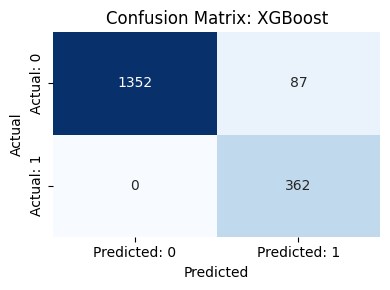

In [18]:
X_train_over, y_train_over_continuous = oversample_data(
    X_train, y_train, y_train_binary
)

y_pred_scores_over, y_pred_binary_over, metrics_over = train_and_evaluate_xgboost(
    X_train_over, y_train_over_continuous, X_test, y_test_binary, params_xg
)

### Print all results

In [19]:
# Create dictionary for XGBoost
metrics_dict_xgb = {
    "Baseline (No Resampling)": metrics_baseline_xgb,
    "1:1 Undersample": metrics_1to1,
    "1.5:1 Undersample": metrics_1_5to1,
    "2:1 Undersample": metrics_2to1,
    "SMOTE Oversample": metrics_over,
}

# Convert to DataFrame
metrics_table_xgb = pd.DataFrame(metrics_dict_xgb).T
metrics_table_xgb = metrics_table_xgb[["accuracy", "precision", "recall", "f1", "auc"]]

# Show the table
print(metrics_table_xgb)

                          accuracy  precision    recall        f1       auc
Baseline (No Resampling)  0.948362   1.000000  0.743094  0.852615  0.990161
1:1 Undersample           0.951694   0.806236  1.000000  0.892725  0.991087
1.5:1 Undersample         0.950028   0.806306  0.988950  0.888337  0.990640
2:1 Undersample           0.941144   0.921053  0.773481  0.840841  0.990295
SMOTE Oversample          0.951694   0.806236  1.000000  0.892725  0.991228


In [20]:
# For XGBoost metrics
metrics_table_xgb.to_csv("xgboost_metrics.csv", index=True)

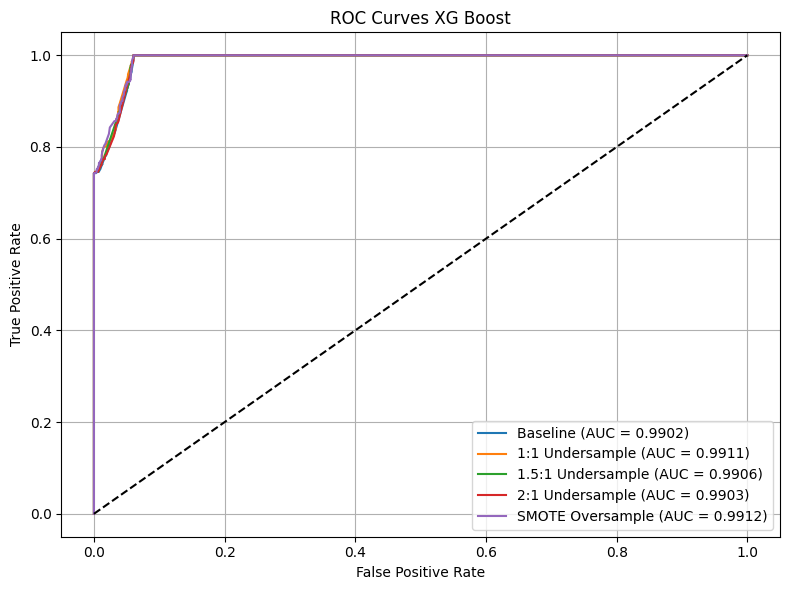

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for each
fpr_baseline_xgb, tpr_baseline_xgb, _ = roc_curve(y_test_binary, y_pred_scores_baseline)
fpr_1to1, tpr_1to1, _ = roc_curve(y_test_binary, y_pred_scores_1to1)
fpr_1_5to1, tpr_1_5to1, _ = roc_curve(y_test_binary, y_pred_scores_1_5to1)
fpr_2to1, tpr_2to1, _ = roc_curve(y_test_binary, y_pred_scores_2to1)
fpr_over, tpr_over, _ = roc_curve(y_test_binary, y_pred_scores_over)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline_xgb,
    tpr_baseline_xgb,
    label="Baseline (AUC = {:.4f})".format(metrics_baseline_xgb["auc"]),
)


plt.plot(
    fpr_1to1,
    tpr_1to1,
    label="1:1 Undersample (AUC = {:.4f})".format(metrics_1to1["auc"]),
)
plt.plot(
    fpr_1_5to1,
    tpr_1_5to1,
    label="1.5:1 Undersample (AUC = {:.4f})".format(metrics_1_5to1["auc"]),
)
plt.plot(
    fpr_2to1,
    tpr_2to1,
    label="2:1 Undersample (AUC = {:.4f})".format(metrics_2to1["auc"]),
)
plt.plot(
    fpr_over,
    tpr_over,
    label="SMOTE Oversample (AUC = {:.4f})".format(metrics_over["auc"]),
)

# Chance line
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves XG Boost")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()